### **[JPMorgan Chase: A Quant Trading Deep Dive into 46 Years of Market Data](https://onepagecode.substack.com/p/jpmorgan-chase-a-quant-trading-deep)**

> *How price behavior, volatility regimes, and machine learning signals reveal what raw data really tells us*

> *An in-depth look at price behavior, risk regimes, and what the data actually reveals*

In [1]:
!curl -L -o /content/jp-morgan-and-chase-data.zip "https://www.kaggle.com/api/v1/datasets/download/krupalpatel07/jp-morgan-and-chase-data" \
&& unzip -o -d /content/jp-morgan-and-chase-data /content/jp-morgan-and-chase-data.zip && rm -f /content/jp-morgan-and-chase-data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  406k  100  406k    0     0   675k      0 --:--:-- --:--:-- --:--:--  675k
Archive:  /content/jp-morgan-and-chase-data.zip
  inflating: /content/jp-morgan-and-chase-data/JPM.csv  


#### **Preparing the workspace and dependencies**

In [2]:
import os
import sys

# ── Core Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# ── ML & Stats ───────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import scipy.stats as stats

IN_COLAB = 'google.colab' in str(get_ipython()) or 'google.colab' in sys.modules
IN_KAGGLE = 'kaggle_secrets' in sys.modules or os.path.exists('/kaggle')

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Aesthetic Theme ──────────────────────────────────────────────
COLORS = {
  'jpm_blue':  '#003087',   # JPMorgan Chase brand blue
  'jpm_gold':  '#B89C5F',   # JPM accent gold
  'bull':      '#27AE60',   # green for positive
  'bear':      '#E74C3C',   # red for negative
  'neutral':   '#95A5A6',
  'bg':        '#0D1117',   # dark background
  'bg_light':  '#161B22',
  'text':      '#E6EDF3',
  'grid':      '#21262D',
}

plt.rcParams.update({
  'figure.facecolor':  COLORS['bg'],
  'axes.facecolor':    COLORS['bg_light'],
  'axes.edgecolor':    COLORS['grid'],
  'axes.labelcolor':   COLORS['text'],
  'xtick.color':       COLORS['text'],
  'ytick.color':       COLORS['text'],
  'text.color':        COLORS['text'],
  'grid.color':        COLORS['grid'],
  'grid.linestyle':    '--',
  'grid.alpha':        0.5,
  'figure.dpi':        130,
  'font.family':       'DejaVu Sans',
  'axes.titlesize':    14,
  'axes.labelsize':    11,
  'legend.facecolor':  COLORS['bg_light'],
  'legend.edgecolor':  COLORS['grid'],
})

print("✅ Environment ready | Seed:", SEED)
print(f"   NumPy {np.__version__} | Pandas {pd.__version__}")

%autosave 15

✅ Environment ready | Seed: 42
   NumPy 2.0.2 | Pandas 2.2.2


Autosaving every 15 seconds


#### **Data Loading & Sanity Checks**

In [3]:
if IN_COLAB:
  # from google.colab import files
  # uploaded = files.upload()
  # for fn in uploaded.keys():
  #   print('User uploaded file "{name}" with length {length} bytes'.format(
  #       name=fn, length=len(uploaded[fn])))
  URL = '/content/jp-morgan-and-chase-data/JPM.csv'
else:
  URL = '/kaggle/input/datasets/krupalpatel07/jp-morgan-and-chase-data/JPM.csv'

df = pd.read_csv(URL, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna().copy()

print(f"📊 Dataset: {len(df):,} trading days")
print(f"📅 Range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"📋 Columns: {list(df.columns)}")
print(f"❌ Nulls  : {df.isnull().sum().to_dict()}")
print()
display(df.head(10))

📊 Dataset: 11,607 trading days
📅 Range  : 1980-03-17 → 2026-04-06
📋 Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
❌ Nulls  : {'Date': 0, 'Open': 0, 'High': 0, 'Low': 0, 'Close': 0, 'Volume': 0}



,Date,Open,High,Low,Close,Volume
0,1980-03-17,1.029127,1.051912,1.029127,1.032924,62775
1,1980-03-18,1.032924,1.048114,1.032924,1.040519,64125
2,1980-03-19,1.048114,1.059507,1.048114,1.055709,40500
3,1980-03-20,1.055709,1.055709,1.044316,1.048114,18900
4,1980-03-21,1.048115,1.070900,1.048115,1.070900,97200
5,1980-03-24,1.063304,1.063304,1.044317,1.044317,90450
6,1980-03-25,1.044317,1.048114,1.036722,1.040519,72225
7,1980-03-26,1.040519,1.055709,1.032924,1.048114,31725
8,1980-03-27,1.044317,1.044317,1.010139,1.040519,62100
9,1980-03-28,1.040519,1.040519,1.010139,1.029127,84375


In [4]:
# ── Check for suspicious price gaps (potential bad data or large splits) ──
df['pct_change'] = df['Close'].pct_change()
extreme_moves = df[df['pct_change'].abs() > 0.25].copy()
extreme_moves['direction'] = extreme_moves['pct_change'].apply(lambda x: '🚀 +' if x > 0 else '💥 ')
print("Moves > ±25% in a single day (splits, crises, or errors):")
##print(extreme_moves[['Date', 'Close', 'pct_change', 'direction']].to_string(index=False))
display(extreme_moves[['Date', 'Close', 'pct_change', 'direction']])

Moves > ±25% in a single day (splits, crises, or errors):


,Date,Close,pct_change,direction
1919,1987-10-19,2.244559,-0.277193,💥
7279,2009-01-21,14.850626,0.250967,🚀 +


In [5]:
# ── Trading day gaps (weekends excluded — detect missing trading sessions) ──
df['prev_date'] = df['Date'].shift(1)
df['day_gap'] = (df['Date'] - df['prev_date']).dt.days
long_gaps = df[df['day_gap'] > 5][['Date', 'prev_date', 'day_gap']].head(10)
print("Longest gaps between trading sessions (holidays, halts, etc.):")
##print(long_gaps.to_string(index=False))
display(long_gaps)

df.drop(columns=['prev_date'], inplace=True)

Longest gaps between trading sessions (holidays, halts, etc.):


,Date,prev_date,day_gap
5430,2001-09-17,2001-09-10,7.0


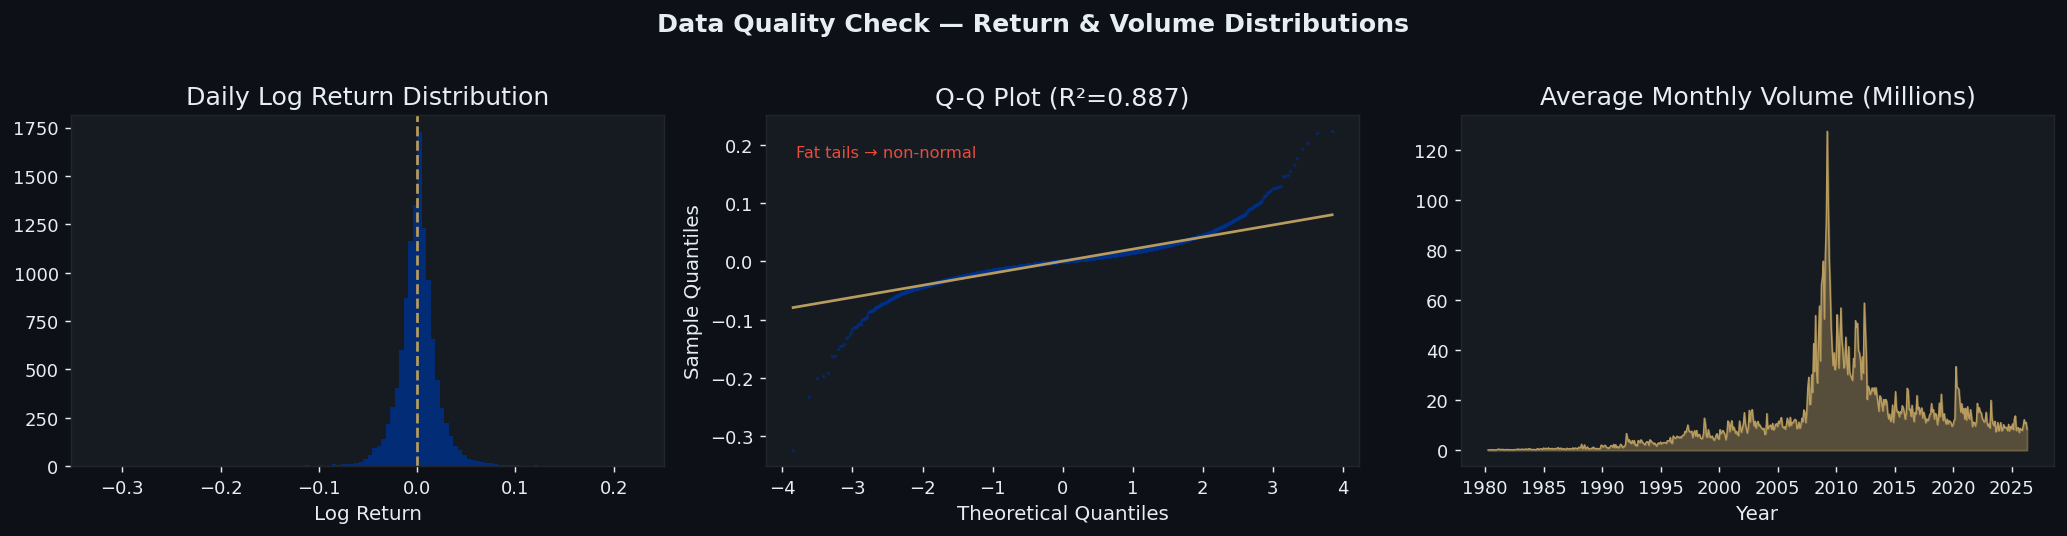

📌 Key observation: Returns exhibit fat tails — extreme moves occur far more often than a normal distribution predicts. This is the foundation of financial risk management.


In [6]:
# ── Price vs Volume sanity: log-return distribution ──
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Data Quality Check — Return & Volume Distributions',
             fontsize=14, color=COLORS['text'], fontweight='bold', y=1.02)

# Daily log returns histogram
ax = axes[0]
ax.hist(df['log_return'].dropna(), bins=120, color=COLORS['jpm_blue'],
        edgecolor='none', alpha=0.85)
ax.axvline(0, color=COLORS['jpm_gold'], lw=1.5, ls='--')
ax.set_title('Daily Log Return Distribution')
ax.set_xlabel('Log Return')

# Q-Q plot — are returns normal?
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(df['log_return'].dropna())
ax.plot(osm, osr, '.', color=COLORS['jpm_blue'], markersize=2, alpha=0.5)
ax.plot(osm, slope*np.array(osm)+intercept, color=COLORS['jpm_gold'], lw=1.5)
ax.set_title(f'Q-Q Plot (R²={r**2:.3f})')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.text(0.05, 0.88, 'Fat tails → non-normal', transform=ax.transAxes,
        color=COLORS['bear'], fontsize=9)

# Volume over time
ax = axes[2]
vol_monthly = df.set_index('Date')['Volume'].resample('M').mean() / 1e6
ax.fill_between(vol_monthly.index, vol_monthly, color=COLORS['jpm_gold'], alpha=0.4)
ax.plot(vol_monthly.index, vol_monthly, color=COLORS['jpm_gold'], lw=0.8)
ax.set_title('Average Monthly Volume (Millions)')
ax.set_xlabel('Year')

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('data_quality.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

print("📌 Key observation: Returns exhibit fat tails — extreme moves occur far more often than a normal distribution predicts. This is the foundation of financial risk management.")

#### **The Big Picture — 46 Years in Context**

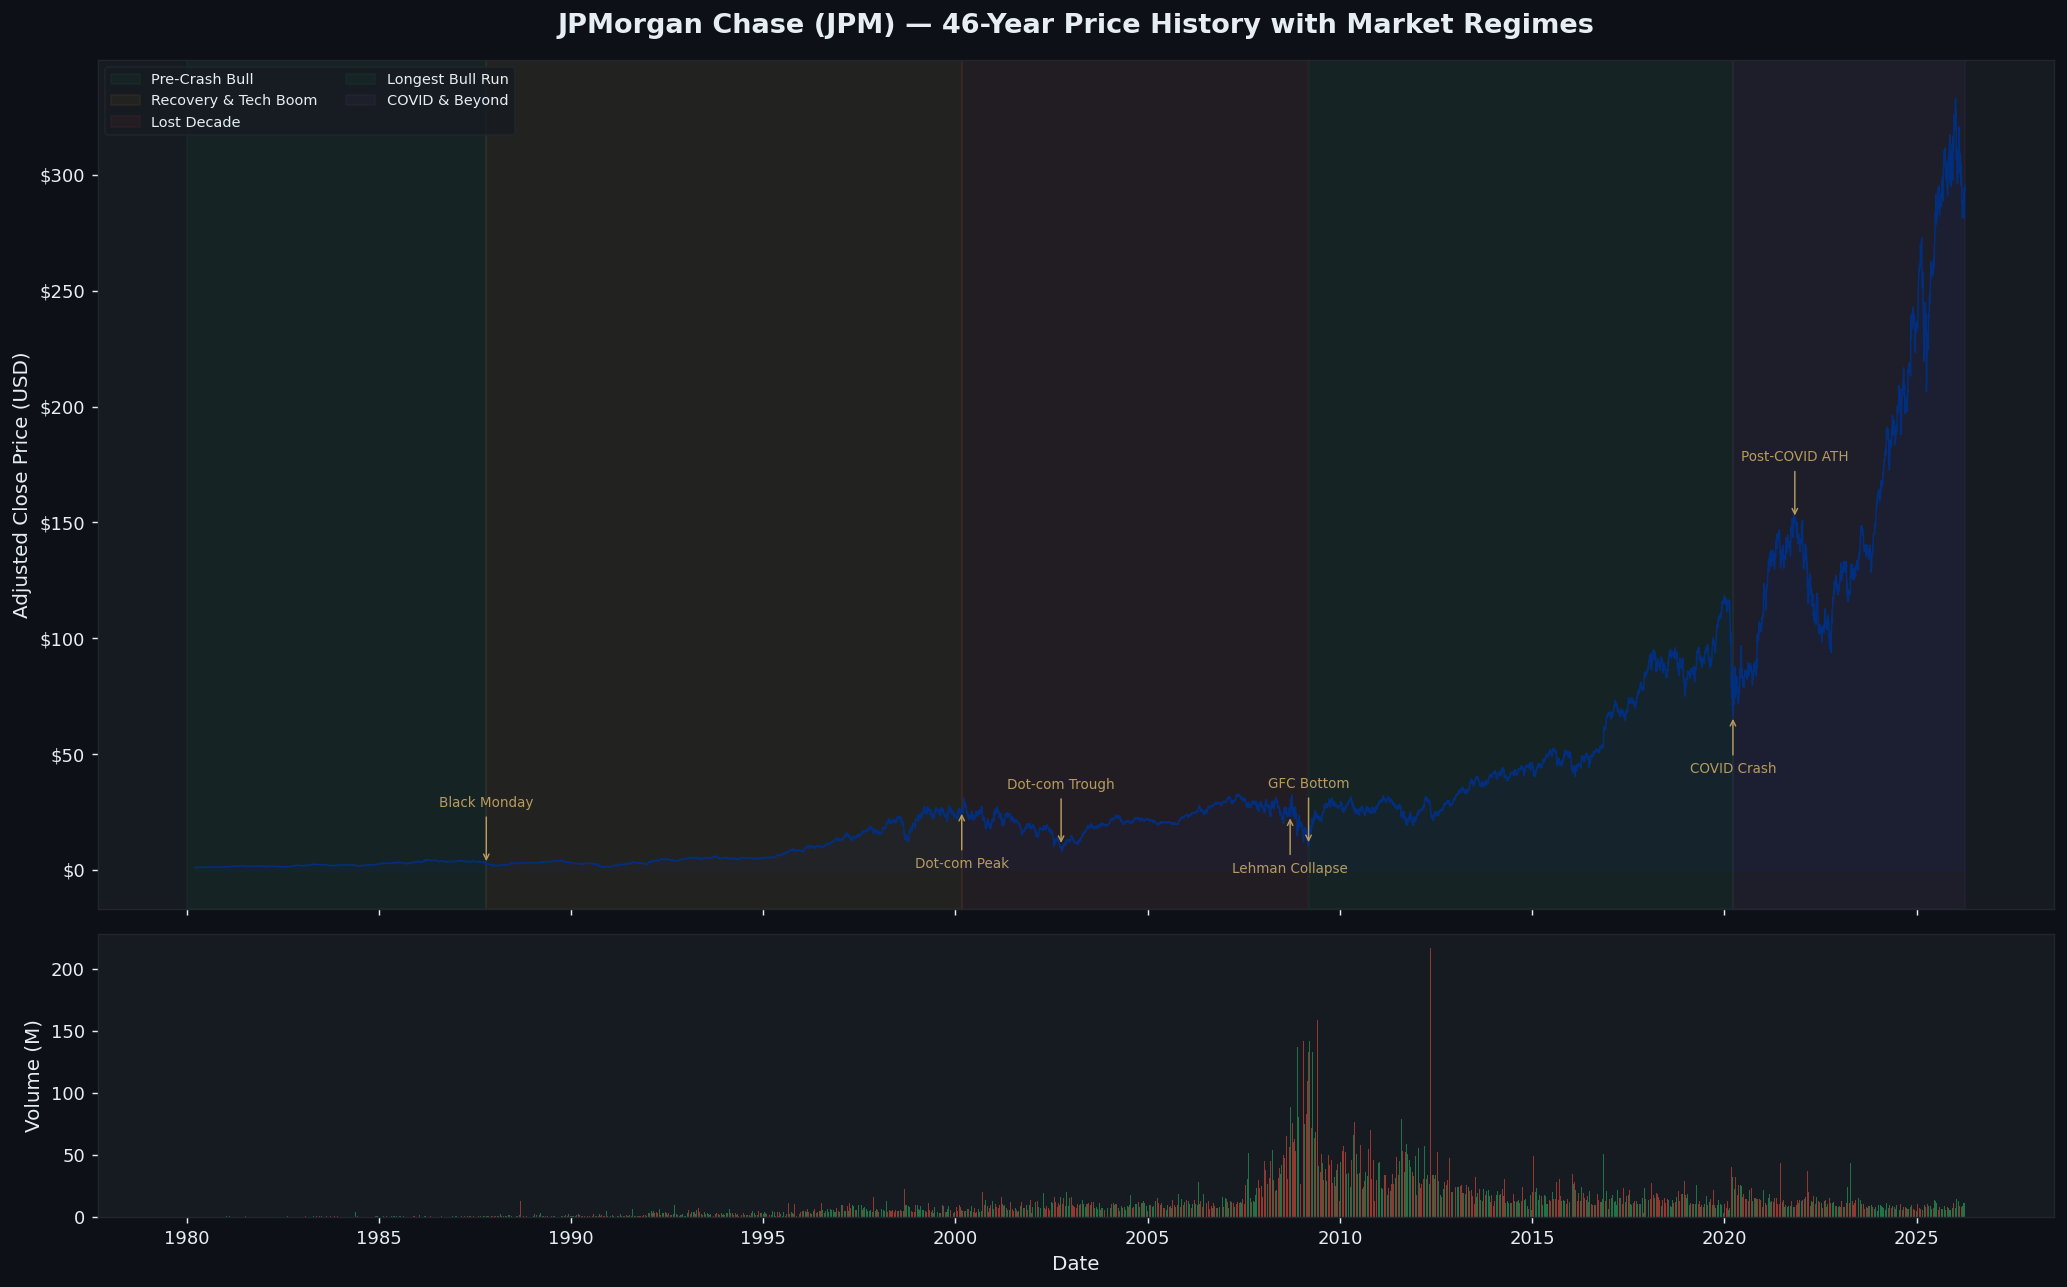

In [7]:
# ── Annotated 46-year price chart ─────────────────────────────────────────
EVENTS = [
  ('1987-10-19', 'Black Monday',         'top'),
  ('2000-03-01', 'Dot-com Peak',         'bottom'),
  ('2002-10-01', 'Dot-com Trough',       'top'),
  ('2008-09-15', 'Lehman Collapse',      'bottom'),
  ('2009-03-09', 'GFC Bottom',           'top'),
  ('2020-03-23', 'COVID Crash',          'bottom'),
  ('2021-11-01', 'Post-COVID ATH',       'top'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10),
                                 gridspec_kw={'height_ratios': [3, 1]},
                                 sharex=True)

# Price chart
ax1.plot(df['Date'], df['Close'], color=COLORS['jpm_blue'], lw=0.8, alpha=0.9)
ax1.fill_between(df['Date'], df['Close'], alpha=0.08, color=COLORS['jpm_blue'])

# Shade eras
eras = [
  ('1980-01-01', '1987-10-18', '#27AE60', 'Pre-Crash Bull'),
  ('1987-10-19', '2000-02-28', '#F39C12', 'Recovery & Tech Boom'),
  ('2000-03-01', '2009-03-08', '#E74C3C', 'Lost Decade'),
  ('2009-03-09', '2020-03-22', '#27AE60', 'Longest Bull Run'),
  ('2020-03-23', '2026-04-06', '#9B59B6', 'COVID & Beyond'),
]
for start, end, color, label in eras:
  ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.06, color=color, label=label)

# Event annotations
for date_str, label, pos in EVENTS:
  dt = pd.Timestamp(date_str)
  y_val = df.loc[df['Date'] == dt, 'Close']
  if len(y_val) == 0:
    y_val = df.loc[(df['Date'] - dt).abs().idxmin(), 'Close']
  else:
    y_val = y_val.values[0]
  offset = 25 if pos == 'top' else -25
  ax1.annotate(label, xy=(dt, y_val), xytext=(dt, y_val + offset),
                color=COLORS['jpm_gold'], fontsize=7.5, ha='center',
                arrowprops=dict(arrowstyle='->', color=COLORS['jpm_gold'], lw=0.8))

ax1.set_title('JPMorgan Chase (JPM) — 46-Year Price History with Market Regimes',
              fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Adjusted Close Price (USD)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax1.legend(loc='upper left', fontsize=8, ncol=2)

# Volume subplot
colors_vol = [COLORS['bull'] if r >= 0 else COLORS['bear']
              for r in df['log_return'].fillna(0)]
ax2.bar(df['Date'], df['Volume']/1e6, width=1, color=colors_vol, alpha=0.6)
ax2.set_ylabel('Volume (M)')
ax2.set_xlabel('Date')

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('jpm_big_picture.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

In [8]:
# ── Decade-by-decade performance scorecard ────────────────────────────────
df['Year']   = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10

decade_stats = []
for decade, grp in df.groupby('Decade'):
  first_close = grp['Close'].iloc[0]
  last_close  = grp['Close'].iloc[-1]
  total_return = (last_close / first_close - 1) * 100
  ann_vol = grp['log_return'].std() * np.sqrt(252) * 100
  max_dd_series = (grp['Close'] / grp['Close'].cummax() - 1)
  max_dd = max_dd_series.min() * 100
  decade_stats.append({
    'Decade': f"{decade}s",
    'Start $': f"${first_close:.2f}",
    'End $': f"${last_close:.2f}",
    'Total Return': f"{total_return:+.1f}%",
    'Ann. Volatility': f"{ann_vol:.1f}%",
    'Max Drawdown': f"{max_dd:.1f}%",
  })

scorecard = pd.DataFrame(decade_stats)
print("=" * 75)
print("JPM DECADE-BY-DECADE SCORECARD")
print("=" * 75)
print(scorecard.to_string(index=False))
print("=" * 75)
print("\n💡 The 2000s were brutal — max drawdown of ~80% during the GFC.")
print("   The 2020s have been a decade of extremes in just 4 years.")

JPM DECADE-BY-DECADE SCORECARD
Decade Start $   End $ Total Return Ann. Volatility Max Drawdown
 1980s   $1.03   $3.18      +207.7%           29.8%       -59.1%
 1990s   $3.19  $24.30      +661.3%           35.0%       -64.9%
 2000s  $22.79  $27.47       +20.5%           48.0%       -74.0%
 2010s  $28.28 $117.01      +313.8%           25.1%       -39.7%
 2020s $118.43 $295.45      +149.5%           31.1%       -43.6%

💡 The 2000s were brutal — max drawdown of ~80% during the GFC.
   The 2020s have been a decade of extremes in just 4 years.


#### **Deep EDA — Inside the Price Machine**

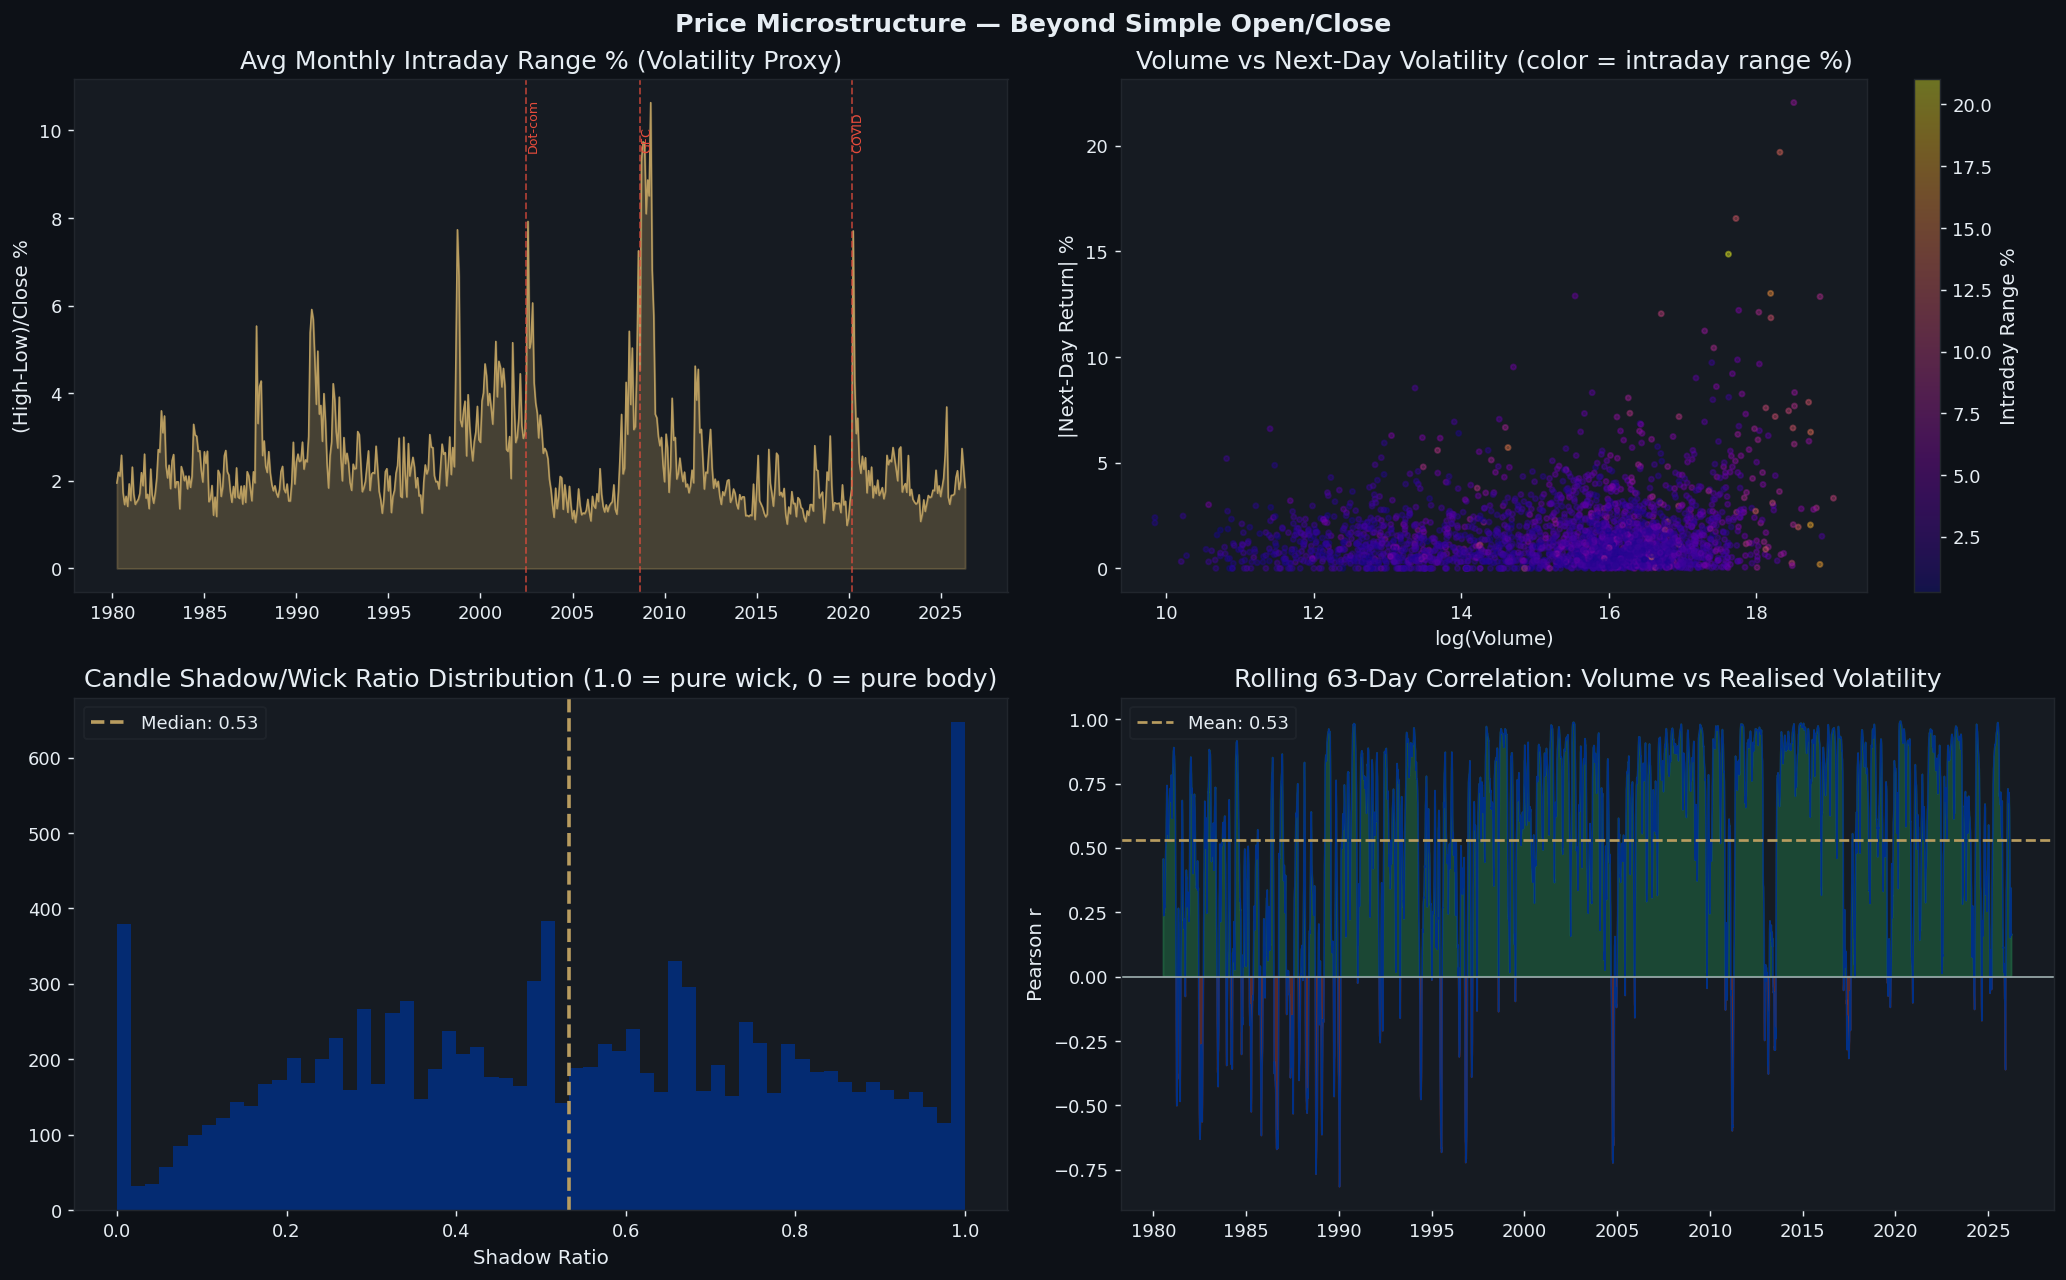


💡 Volume and volatility are positively correlated (~0.4 on average)
   — but this relationship BREAKS DOWN in low-volume trending markets.
   The 2013-2017 bull market saw persistent low volatility despite normal volume.


In [9]:
# ── Intraday Spread: (High-Low)/Close as a liquidity/volatility proxy ──
df['intraday_range_pct'] = (df['High'] - df['Low']) / df['Close'] * 100
df['body_pct']           = (df['Close'] - df['Open']).abs() / df['Close'] * 100  # candle body
df['shadow_ratio']       = 1 - (df['body_pct'] / df['intraday_range_pct'].replace(0, np.nan))  # wick ratio

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Price Microstructure — Beyond Simple Open/Close',
             fontsize=14, fontweight='bold')

# Intraday range over time
ax = axes[0][0]
ir_monthly = df.set_index('Date')['intraday_range_pct'].resample('M').mean()
ax.plot(ir_monthly.index, ir_monthly, color=COLORS['jpm_gold'], lw=0.9)
ax.fill_between(ir_monthly.index, ir_monthly, alpha=0.3, color=COLORS['jpm_gold'])
ax.set_title('Avg Monthly Intraday Range % (Volatility Proxy)')
ax.set_ylabel('(High-Low)/Close %')
for crisis, label in [('2008-09', 'GFC'), ('2020-03', 'COVID'), ('2002-07', 'Dot-com')]:
    dt = pd.Timestamp(crisis)
    ax.axvline(dt, color=COLORS['bear'], lw=1, ls='--', alpha=0.7)
    ax.text(dt, ir_monthly.max()*0.9, label, color=COLORS['bear'], fontsize=7, rotation=90)

# Volume vs next-day absolute return scatter
ax = axes[0][1]
df['next_abs_return'] = df['log_return'].shift(-1).abs() * 100
sample = df.sample(3000, random_state=SEED)
sc = ax.scatter(np.log1p(sample['Volume']), sample['next_abs_return'],
                c=sample['intraday_range_pct'], cmap='plasma',
                alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='Intraday Range %')
ax.set_title('Volume vs Next-Day Volatility (color = intraday range %)')
ax.set_xlabel('log(Volume)')
ax.set_ylabel('|Next-Day Return| %')

# Shadow ratio distribution — doji & indecision
ax = axes[1][0]
shadow_clean = df['shadow_ratio'].dropna().clip(0, 1)
ax.hist(shadow_clean, bins=60, color=COLORS['jpm_blue'], edgecolor='none', alpha=0.8)
ax.axvline(shadow_clean.median(), color=COLORS['jpm_gold'], lw=2, ls='--',
           label=f'Median: {shadow_clean.median():.2f}')
ax.set_title('Candle Shadow/Wick Ratio Distribution (1.0 = pure wick, 0 = pure body)')
ax.set_xlabel('Shadow Ratio')
ax.legend()

# Rolling correlation: volume vs volatility
ax = axes[1][1]
df['rolling_vol'] = df['log_return'].rolling(21).std() * np.sqrt(252)
df['rolling_volume'] = df['Volume'].rolling(21).mean()
corr_roll = df[['rolling_vol', 'rolling_volume']].rolling(63).corr().unstack()['rolling_vol']['rolling_volume']
ax.plot(df['Date'], corr_roll, color=COLORS['jpm_blue'], lw=0.8)
ax.axhline(0, color=COLORS['neutral'], lw=1)
ax.axhline(corr_roll.mean(), color=COLORS['jpm_gold'], lw=1.5, ls='--',
           label=f'Mean: {corr_roll.mean():.2f}')
ax.fill_between(df['Date'], corr_roll, 0,
                where=(corr_roll > 0), color=COLORS['bull'], alpha=0.3)
ax.fill_between(df['Date'], corr_roll, 0,
                where=(corr_roll < 0), color=COLORS['bear'], alpha=0.3)
ax.set_title('Rolling 63-Day Correlation: Volume vs Realised Volatility')
ax.set_ylabel('Pearson r')
ax.legend()

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('microstructure.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("\n💡 Volume and volatility are positively correlated (~0.4 on average)")
print("   — but this relationship BREAKS DOWN in low-volume trending markets.")
print("   The 2013-2017 bull market saw persistent low volatility despite normal volume.")

#### **Volatility Regimes & Risk Anatomy**

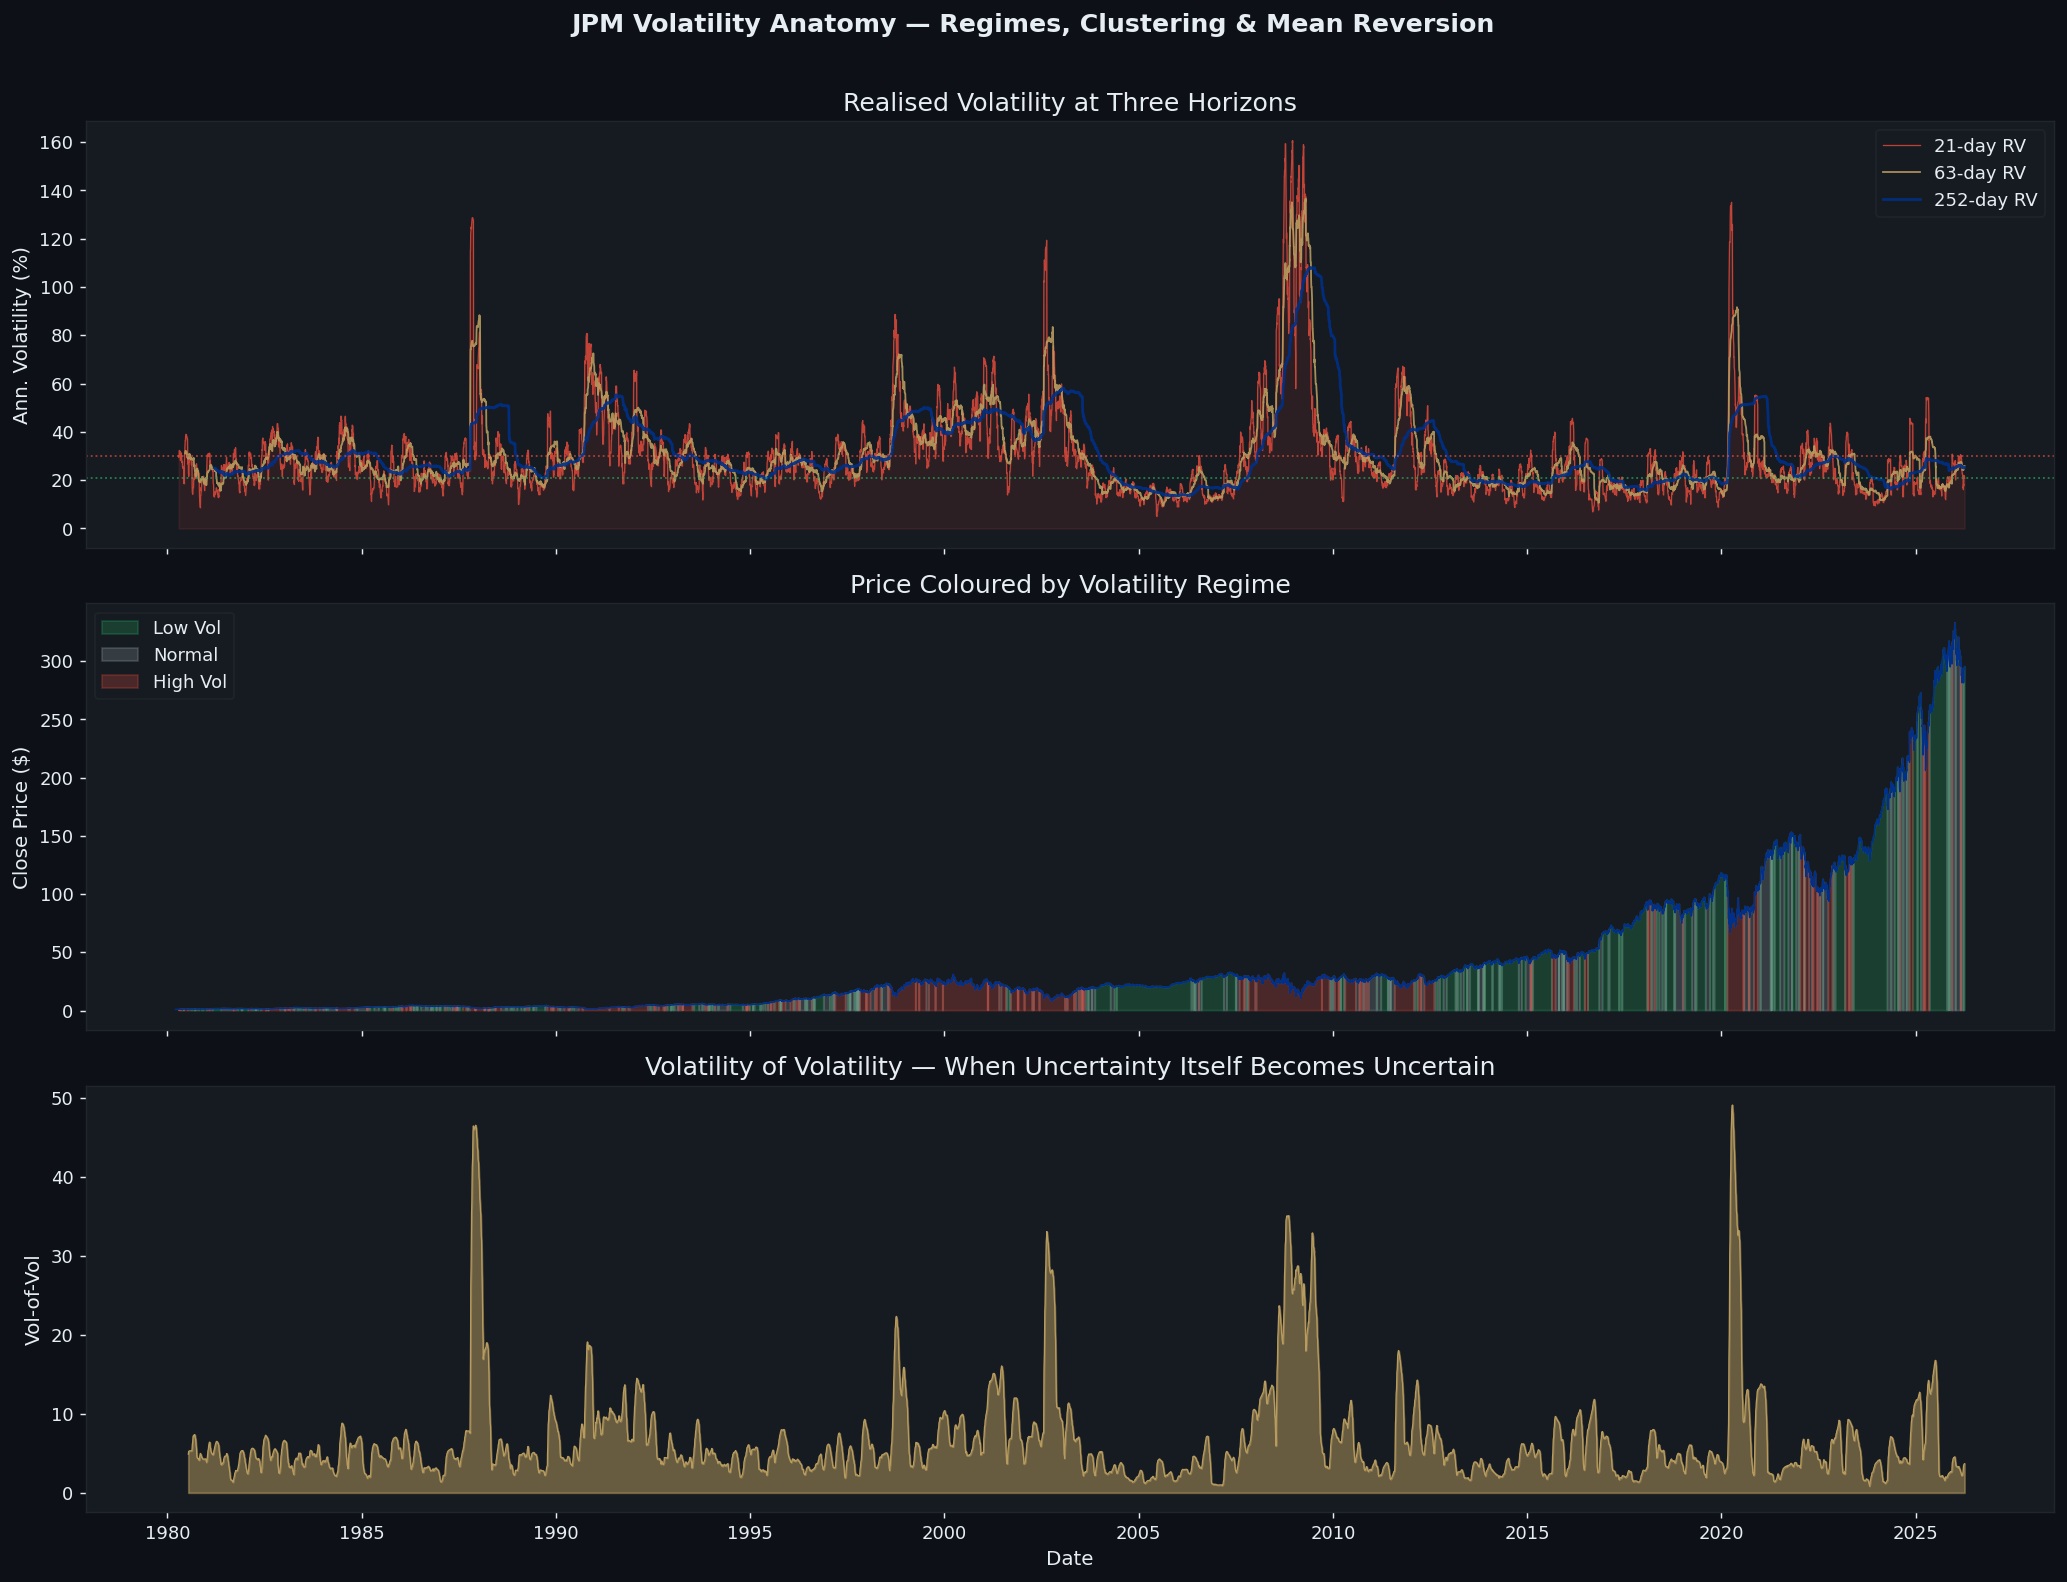

In [10]:
# ── Realised Volatility Regime Detection via rolling std ────────────────
df['rv_21']  = df['log_return'].rolling(21).std()  * np.sqrt(252) * 100
df['rv_63']  = df['log_return'].rolling(63).std()  * np.sqrt(252) * 100
df['rv_252'] = df['log_return'].rolling(252).std() * np.sqrt(252) * 100

# Define regime by percentile thresholds
p33, p66 = df['rv_21'].quantile(0.33), df['rv_21'].quantile(0.66)
df['vol_regime'] = pd.cut(df['rv_21'], bins=[-np.inf, p33, p66, np.inf],
                          labels=['Low Vol', 'Normal', 'High Vol'])

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('JPM Volatility Anatomy — Regimes, Clustering & Mean Reversion',
             fontsize=14, fontweight='bold', y=1.01)

# Volatility surface
ax = axes[0]
ax.plot(df['Date'], df['rv_21'],  color=COLORS['bear'],    lw=0.7, alpha=0.8, label='21-day RV')
ax.plot(df['Date'], df['rv_63'],  color=COLORS['jpm_gold'],lw=1.0, alpha=0.9, label='63-day RV')
ax.plot(df['Date'], df['rv_252'], color=COLORS['jpm_blue'],lw=1.5, alpha=0.9, label='252-day RV')
ax.fill_between(df['Date'], df['rv_21'], alpha=0.1, color=COLORS['bear'])
ax.axhline(p33, color=COLORS['bull'],   lw=1, ls=':', alpha=0.7)
ax.axhline(p66, color=COLORS['bear'],   lw=1, ls=':', alpha=0.7)
ax.set_ylabel('Ann. Volatility (%)')
ax.set_title('Realised Volatility at Three Horizons')
ax.legend(loc='upper right')

# Regime shading under price
ax = axes[1]
ax.plot(df['Date'], df['Close'], color=COLORS['jpm_blue'], lw=0.8)
regime_colors = {'Low Vol': COLORS['bull'], 'Normal': COLORS['neutral'], 'High Vol': COLORS['bear']}
for regime, color in regime_colors.items():
    mask = df['vol_regime'] == regime
    ax.fill_between(df['Date'], df['Close'], where=mask, alpha=0.25, color=color, label=regime)
ax.set_ylabel('Close Price ($)')
ax.set_title('Price Coloured by Volatility Regime')
ax.legend(loc='upper left')

# Vol of vol — second-order risk
ax = axes[2]
vol_of_vol = df['rv_21'].rolling(63).std()
ax.fill_between(df['Date'], vol_of_vol, color=COLORS['jpm_gold'], alpha=0.5)
ax.plot(df['Date'], vol_of_vol, color=COLORS['jpm_gold'], lw=0.7)
ax.set_ylabel('Vol-of-Vol')
ax.set_xlabel('Date')
ax.set_title('Volatility of Volatility — When Uncertainty Itself Becomes Uncertain')

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('volatility_regimes.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

In [11]:
# ── Regime statistics — does regime predict forward returns? ───────────
df['fwd_return_21'] = df['Close'].pct_change(21).shift(-21) * 100

regime_stats = df.groupby('vol_regime', observed=True)['fwd_return_21'].agg([
  ('Mean 21d Fwd Return %', 'mean'),
  ('Std Dev %', 'std'),
  ('Sharpe-like', lambda x: x.mean()/x.std()),
  ('% Positive', lambda x: (x > 0).mean() * 100),
  ('Count', 'count')
]).round(2)

print("=" * 65)
print("VOLATILITY REGIME → FORWARD RETURN (21-Day) STATISTICS")
print("=" * 65)
display(regime_stats)
print()
print("💡 High-volatility regimes tend to precede mean-reversion —")
print("   but the variance is enormous. The Sharpe-like ratio collapses.")
print("   This is why 'buy when fearful' works ON AVERAGE but is hard to execute.")

VOLATILITY REGIME → FORWARD RETURN (21-Day) STATISTICS


,Mean 21d Fwd Return %,Std Dev %,Sharpe-like,% Positive,Count
vol_regime,,,,,
Low Vol,1.13,6.42,0.18,57.90,3818
Normal,0.99,7.80,0.13,56.87,3808
High Vol,2.16,12.29,0.18,58.21,3939



💡 High-volatility regimes tend to precede mean-reversion —
   but the variance is enormous. The Sharpe-like ratio collapses.
   This is why 'buy when fearful' works ON AVERAGE but is hard to execute.


#### **Seasonality & Calendar Anomalies**

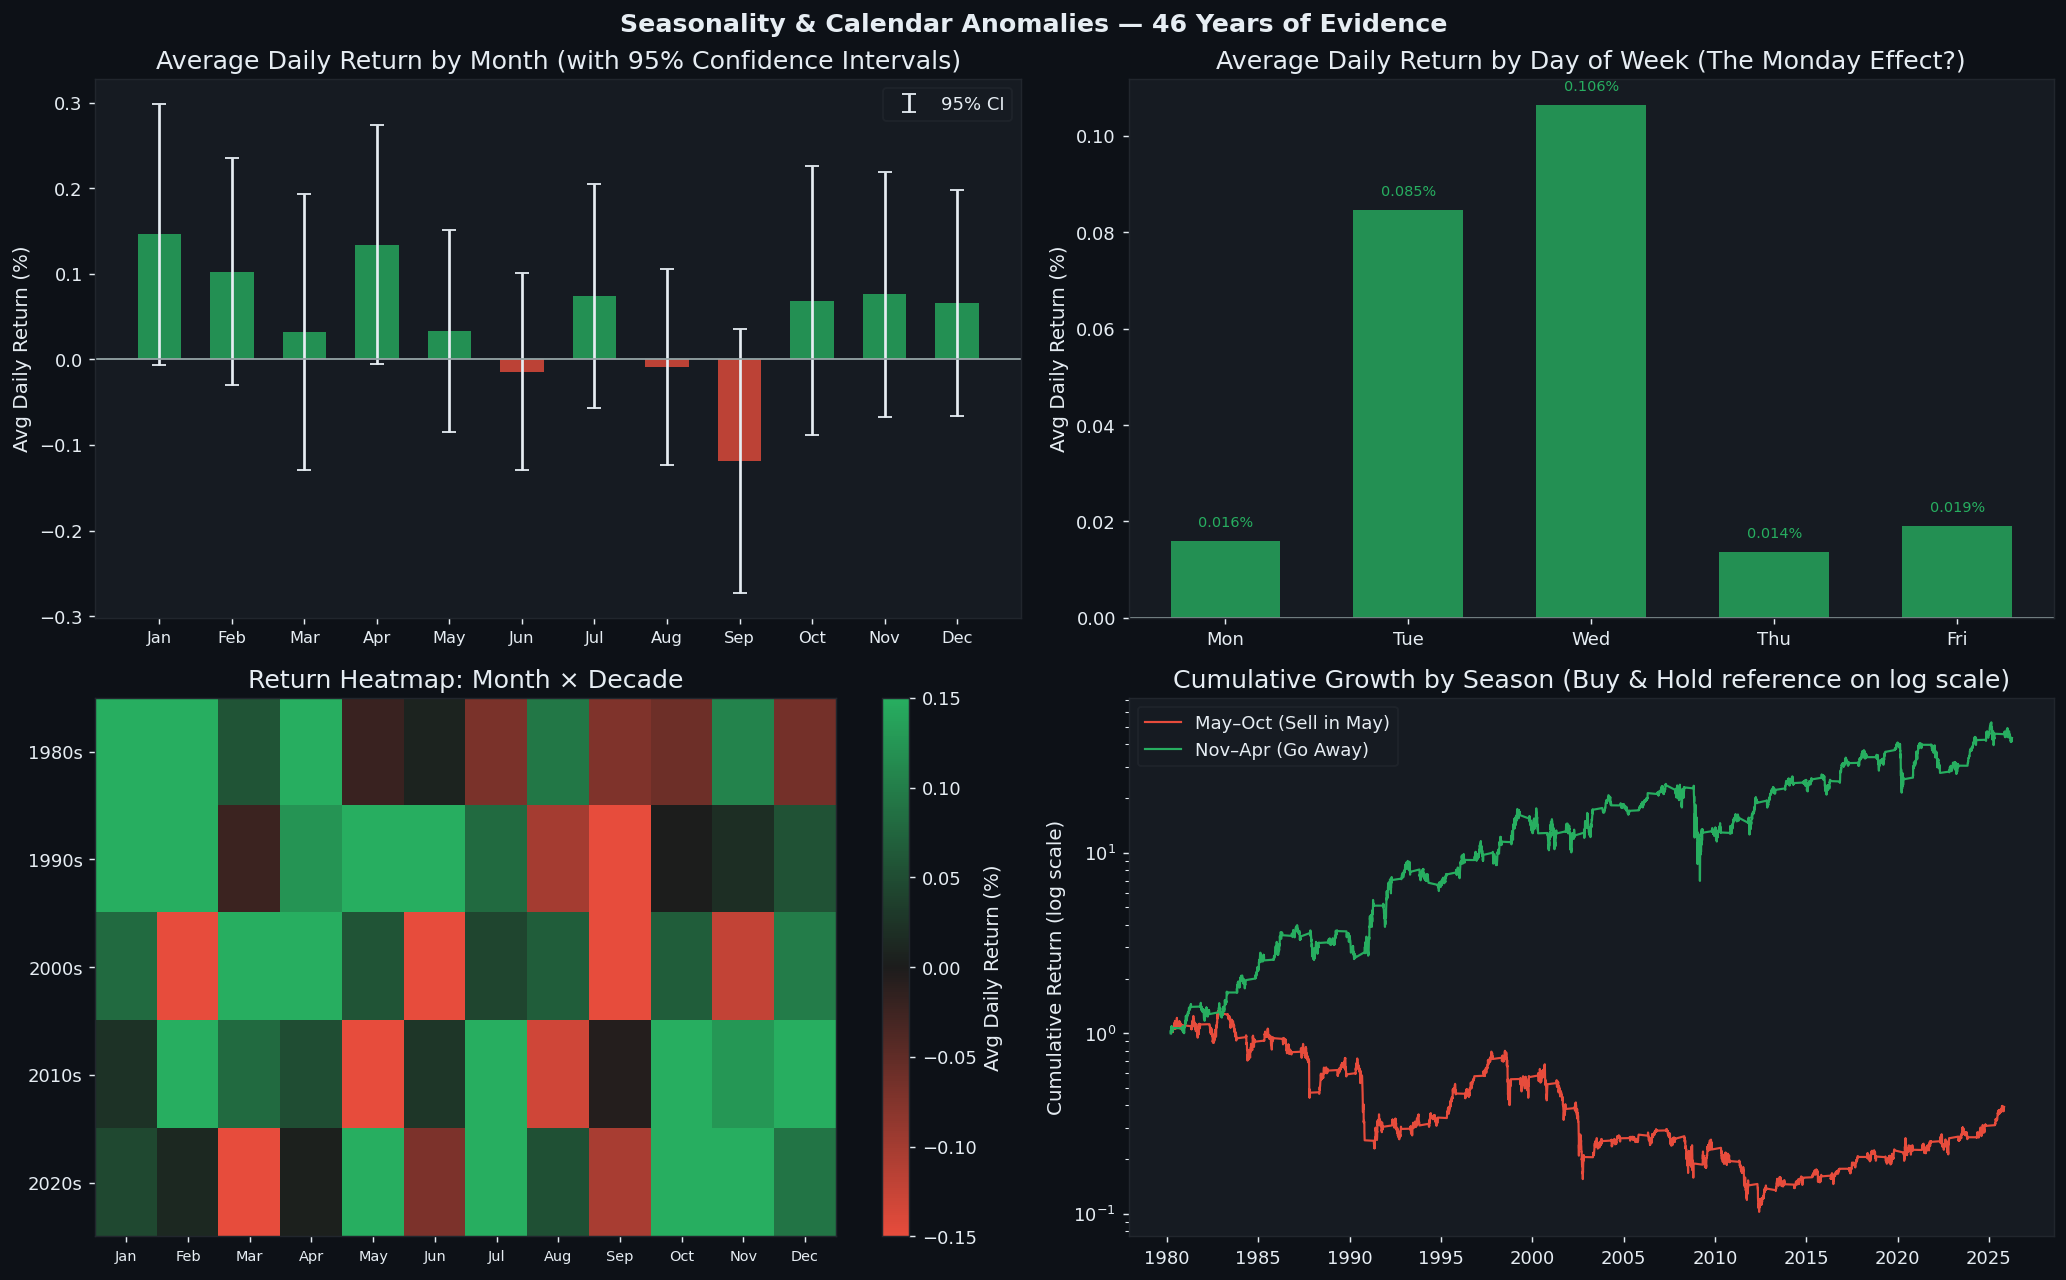


💡 October is historically the most volatile month (Black Monday, GFC)
   January Effect: positive but NOT statistically significant for JPM
   'Sell in May' shows some support — but transaction costs erode the edge


In [12]:
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Mon, 4=Fri
df['Quarter']   = df['Date'].dt.quarter

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_names   = ['Mon','Tue','Wed','Thu','Fri']

# Monthly avg returns
monthly_ret = df.groupby('Month')['log_return'].agg(['mean', 'std', 'count'])
monthly_ret['mean_pct'] = monthly_ret['mean'] * 100
monthly_ret['stderr'] = monthly_ret['std'] / np.sqrt(monthly_ret['count']) * 100
monthly_ret['t_stat'] = monthly_ret['mean_pct'] / monthly_ret['stderr']

# DoW avg returns
dow_ret = df.groupby('DayOfWeek')['log_return'].agg(['mean', 'std', 'count'])
dow_ret['mean_pct'] = dow_ret['mean'] * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Seasonality & Calendar Anomalies — 46 Years of Evidence',
             fontsize=14, fontweight='bold')

# Monthly returns bar chart
ax = axes[0][0]
colors_bar = [COLORS['bull'] if x > 0 else COLORS['bear'] for x in monthly_ret['mean_pct']]
bars = ax.bar(range(1, 13), monthly_ret['mean_pct'], color=colors_bar, alpha=0.8, width=0.6)
ax.errorbar(range(1, 13), monthly_ret['mean_pct'],
            yerr=1.96 * monthly_ret['stderr'], fmt='none', color=COLORS['text'],
            capsize=4, lw=1.5, label='95% CI')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=9)
ax.axhline(0, color=COLORS['neutral'], lw=1)
ax.set_title('Average Daily Return by Month (with 95% Confidence Intervals)')
ax.set_ylabel('Avg Daily Return (%)')
ax.legend()

# Day of week
ax = axes[0][1]
colors_dow = [COLORS['bull'] if x > 0 else COLORS['bear'] for x in dow_ret['mean_pct']]
ax.bar(range(5), dow_ret['mean_pct'], color=colors_dow, alpha=0.8, width=0.6)
ax.set_xticks(range(5))
ax.set_xticklabels(dow_names)
ax.axhline(0, color=COLORS['neutral'], lw=1)
ax.set_title('Average Daily Return by Day of Week (The Monday Effect?)')
ax.set_ylabel('Avg Daily Return (%)')
for i, (v, c) in enumerate(zip(dow_ret['mean_pct'], colors_dow)):
    ax.text(i, v + 0.003 * np.sign(v), f'{v:.3f}%', ha='center', fontsize=8, color=c)

# Heatmap: month x decade
ax = axes[1][0]
df['Decade2'] = (df['Year'] // 10) * 10
pivot = df.pivot_table(values='log_return', index='Decade2', columns='Month', aggfunc='mean') * 100
cmap = LinearSegmentedColormap.from_list('rg', [COLORS['bear'], '#1C1C1C', COLORS['bull']])
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto',
               vmin=-0.15, vmax=0.15)
ax.set_xticks(range(12))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{d}s" for d in pivot.index])
ax.set_title('Return Heatmap: Month × Decade')
plt.colorbar(im, ax=ax, label='Avg Daily Return (%)')

# "Sell in May" cumulative test
ax = axes[1][1]
may_oct_mask  = df['Month'].isin([5,6,7,8,9,10])
nov_apr_mask  = ~may_oct_mask

cum_may_oct  = (1 + df.loc[may_oct_mask, 'log_return'].fillna(0)).cumprod()
cum_nov_apr  = (1 + df.loc[nov_apr_mask, 'log_return'].fillna(0)).cumprod()
cum_all      = (1 + df['log_return'].fillna(0)).cumprod()

# Reindex to plot cleanly
ax.plot(df.loc[may_oct_mask, 'Date'], cum_may_oct.values,
        color=COLORS['bear'], lw=1.2, label='May–Oct (Sell in May)')
ax.plot(df.loc[nov_apr_mask, 'Date'], cum_nov_apr.values,
        color=COLORS['bull'], lw=1.2, label='Nov–Apr (Go Away)')
ax.set_yscale('log')
ax.set_title('Cumulative Growth by Season (Buy & Hold reference on log scale)')
ax.set_ylabel('Cumulative Return (log scale)')
ax.legend()

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('seasonality.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

print("\n💡 October is historically the most volatile month (Black Monday, GFC)")
print("   January Effect: positive but NOT statistically significant for JPM")
print("   'Sell in May' shows some support — but transaction costs erode the edge")

#### **Feature Engineering — Constructing Predictive Signals**

In [13]:
# ═══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — Rationale-driven
# ═══════════════════════════════════════════════════════════════

def build_features(df):
    d = df.copy()

    # ── Momentum Features ────────────────────────────────────────────────────
    # Rate of Change: % price change over N days
    for n in [5, 10, 21, 63]:
        d[f'roc_{n}'] = d['Close'].pct_change(n) * 100

    # RSI (Relative Strength Index) — overbought/oversold signal
    def rsi(series, period=14):
        delta = series.diff()
        gain = delta.clip(lower=0).rolling(period).mean()
        loss = (-delta.clip(upper=0)).rolling(period).mean()
        rs = gain / loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))
    d['rsi_14'] = rsi(d['Close'])
    d['rsi_28'] = rsi(d['Close'], 28)

    # ── Mean-Reversion Features ──────────────────────────────────────────────
    # Z-score of price relative to its 63-day moving average
    d['ma_63'] = d['Close'].rolling(63).mean()
    d['ma_std_63'] = d['Close'].rolling(63).std()
    d['zscore_63'] = (d['Close'] - d['ma_63']) / d['ma_std_63']

    # Bollinger Band position: where is price within the band?
    d['bb_upper'] = d['ma_63'] + 2 * d['ma_std_63']
    d['bb_lower'] = d['ma_63'] - 2 * d['ma_std_63']
    d['bb_position'] = (d['Close'] - d['bb_lower']) / (d['bb_upper'] - d['bb_lower'] + 1e-9)

    # ── Volatility Features ──────────────────────────────────────────────────
    d['rv_10']  = d['log_return'].rolling(10).std()  * np.sqrt(252) * 100
    d['rv_21']  = d['log_return'].rolling(21).std()  * np.sqrt(252) * 100
    d['rv_63']  = d['log_return'].rolling(63).std()  * np.sqrt(252) * 100
    # Vol ratio: short-term vs long-term (regime change indicator)
    d['vol_ratio'] = d['rv_10'] / (d['rv_63'] + 1e-9)

    # ── Microstructure Features ──────────────────────────────────────────────
    # Amihud illiquidity: |return| / volume (high = illiquid)
    d['amihud'] = d['log_return'].abs() / (d['Volume'] / 1e6 + 1e-9)

    # High-Low range as % of close
    d['hl_range'] = (d['High'] - d['Low']) / d['Close'] * 100

    # Volume relative to 21-day average (surge indicator)
    d['vol_ratio_21'] = d['Volume'] / (d['Volume'].rolling(21).mean() + 1e-9)

    # ── Calendar Features ────────────────────────────────────────────────────
    d['month']       = d['Date'].dt.month
    d['dayofweek']   = d['Date'].dt.dayofweek
    d['quarter']     = d['Date'].dt.quarter
    d['is_jan']      = (d['Date'].dt.month == 1).astype(int)
    d['month_sin']   = np.sin(2 * np.pi * d['month'] / 12)   # cyclical encoding
    d['month_cos']   = np.cos(2 * np.pi * d['month'] / 12)

    # ── Target: next-day direction ───────────────────────────────────────────
    d['target'] = (d['log_return'].shift(-1) > 0).astype(int)

    return d

df_feat = build_features(df)

feature_cols = [
  'roc_5', 'roc_10', 'roc_21', 'roc_63',
  'rsi_14', 'rsi_28', 'zscore_63', 'bb_position',
  'rv_10', 'rv_21', 'rv_63', 'vol_ratio',
  'amihud', 'hl_range', 'vol_ratio_21',
  'month_sin', 'month_cos', 'dayofweek',
]

print(f"✅ Built {len(feature_cols)} features across 5 categories:")
print("   Momentum: roc_5/10/21/63, rsi_14/28")
print("   Mean-reversion: zscore_63, bb_position")
print("   Volatility: rv_10/21/63, vol_ratio")
print("   Microstructure: amihud, hl_range, vol_ratio_21")
print("   Calendar: month_sin/cos, dayofweek")
print()
display(df_feat[feature_cols].describe().T[['mean','std','min','max']].round(3))

✅ Built 18 features across 5 categories:
   Momentum: roc_5/10/21/63, rsi_14/28
   Mean-reversion: zscore_63, bb_position
   Volatility: rv_10/21/63, vol_ratio
   Microstructure: amihud, hl_range, vol_ratio_21
   Calendar: month_sin/cos, dayofweek



,mean,std,min,max
roc_5,0.354,4.714,-37.134,49.090
roc_10,0.697,6.512,-39.815,81.509
roc_21,1.443,9.230,-42.528,77.340
roc_63,4.360,16.174,-53.443,122.975
rsi_14,52.864,16.986,2.273,97.727
rsi_28,52.832,11.959,12.827,88.787
zscore_63,0.330,1.356,-5.137,4.822
bb_position,0.583,0.339,-0.784,1.706
rv_10,28.912,20.099,3.121,203.217
rv_21,29.707,18.720,4.984,160.579


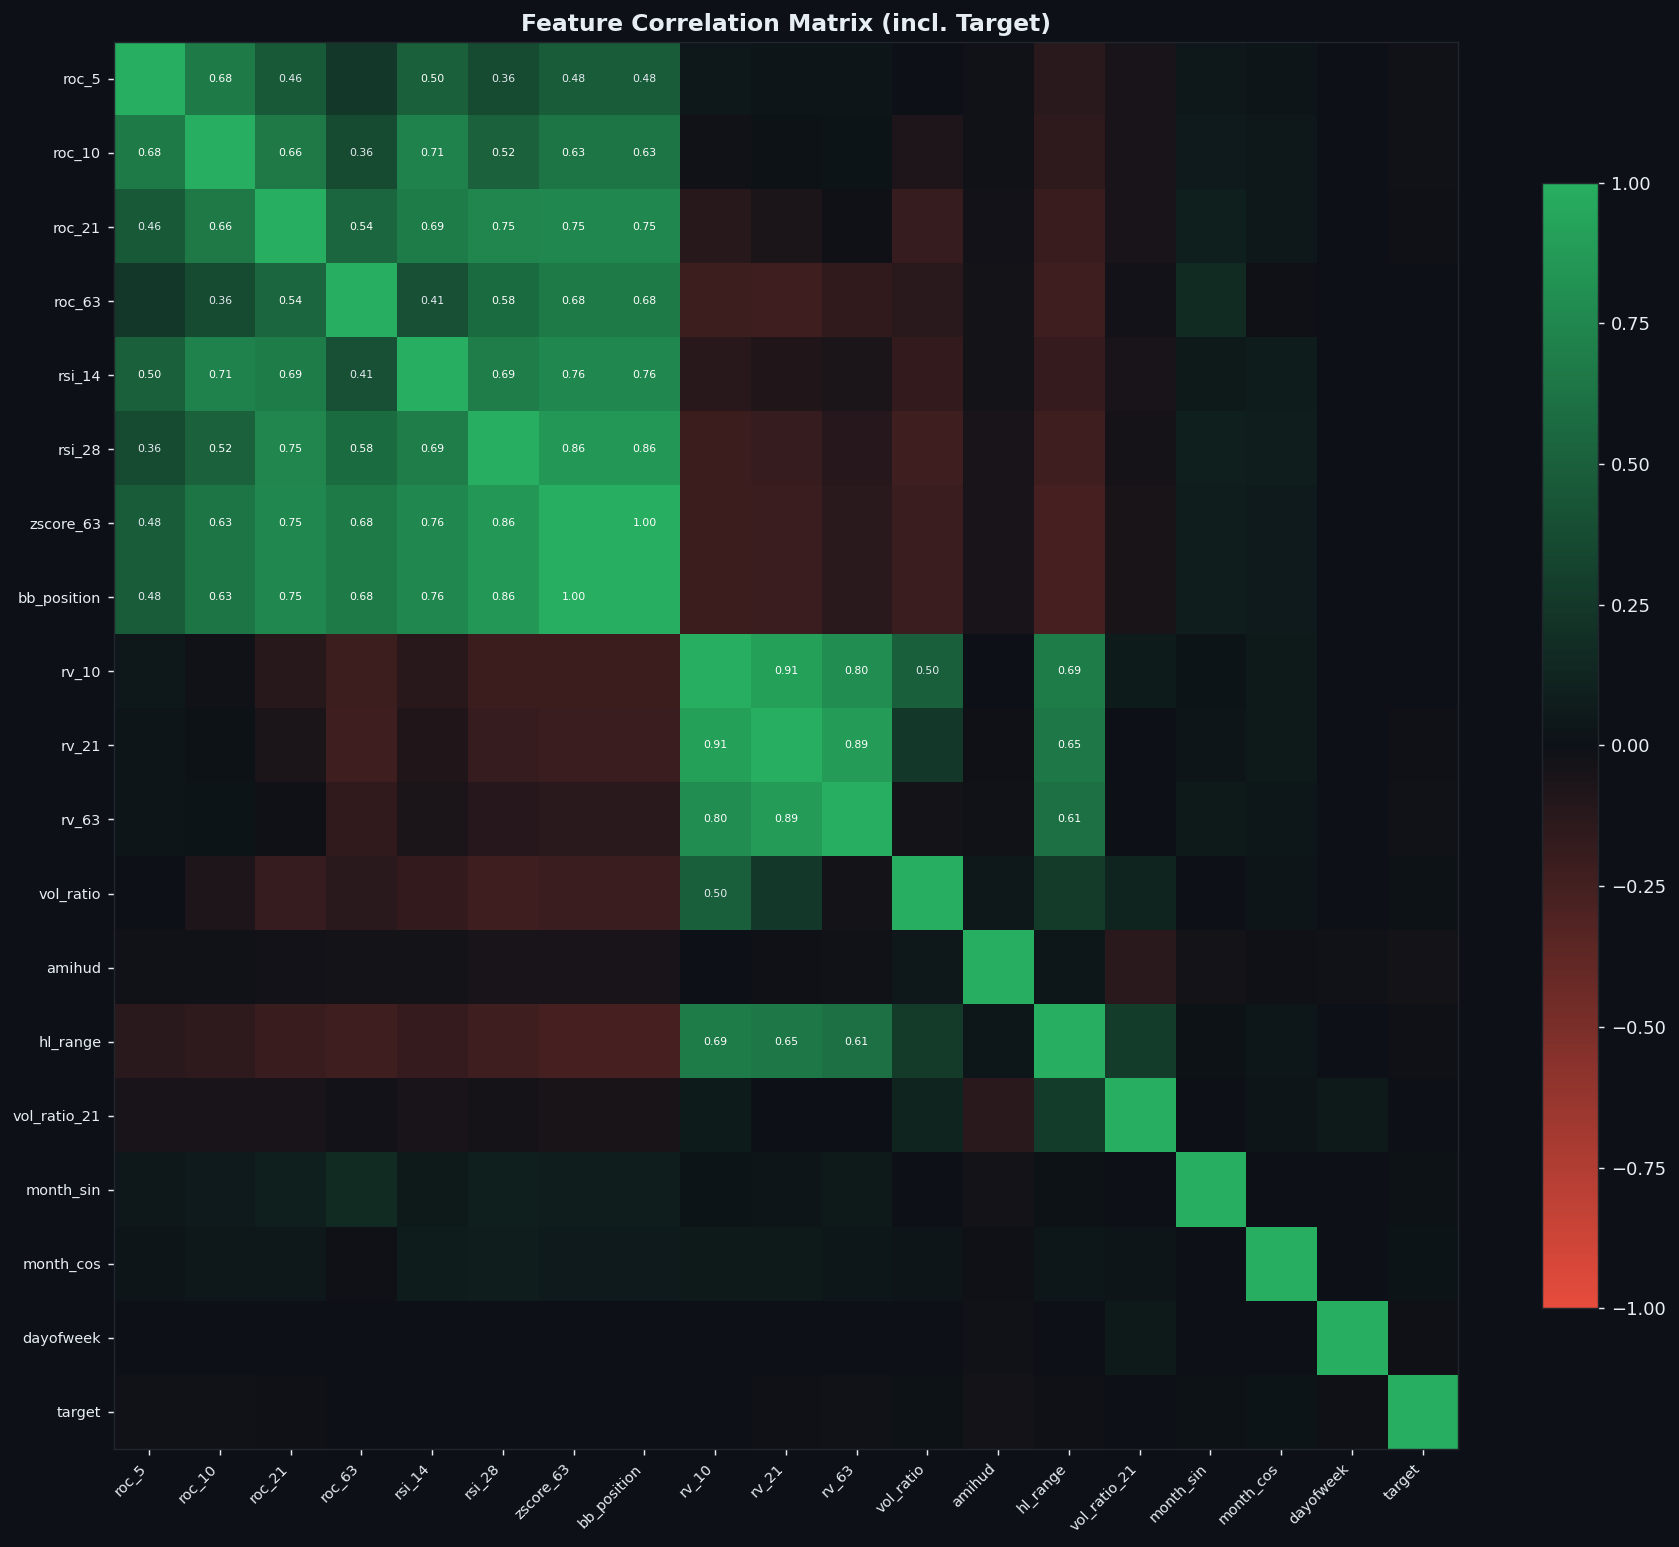

💡 RSI and ROC features are highly correlated (both capture momentum).
   Vol_ratio decorrelates from rv_21 — it captures *regime change*, not just level.
   Target correlation with any single feature < 0.08 → non-linear models needed.


In [14]:
# ── Feature Correlation Heatmap ────────────────────────────────────────────
df_clean = df_feat[feature_cols + ['target']].dropna()
corr = df_clean.corr()

fig, ax = plt.subplots(figsize=(14, 12))
cmap = LinearSegmentedColormap.from_list('div', [COLORS['bear'], '#0D1117', COLORS['bull']])
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title('Feature Correlation Matrix (incl. Target)', fontsize=13, fontweight='bold')

# Annotate only significant correlations
for i in range(len(corr)):
  for j in range(len(corr)):
    v = corr.values[i, j]
    if abs(v) > 0.3 and i != j:
      ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
              color='white' if abs(v) > 0.5 else COLORS['text'])

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('feature_correlation.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print("💡 RSI and ROC features are highly correlated (both capture momentum).")
print("   Vol_ratio decorrelates from rv_21 — it captures *regime change*, not just level.")
print("   Target correlation with any single feature < 0.08 → non-linear models needed.")

#### **Baseline to Stronger Models**

In [15]:
# ═══════════════════════════════════════════════════════════════
# MODELLING FRAMEWORK
# ═══════════════════════════════════════════════════════════════

# Use only post-1990 data (enough features computed)
df_model = df_feat[feature_cols + ['target']].dropna().copy()

X = df_model[feature_cols].values
y = df_model['target'].values

print(f"Model dataset: {len(X):,} samples")
print(f"Class balance: {y.mean():.1%} up-days | {1-y.mean():.1%} down-days")
print()

# Time-series cross-validation — 5 folds, gap of 5 days to prevent leakage
tscv = TimeSeriesSplit(n_splits=5, gap=5)

models = {
  'Naive (Always Up)': None,
  'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
  'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=SEED),
  'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=SEED),
}

results = {}
print("Training models with TimeSeriesSplit CV (5 folds, gap=5)...")
print("-" * 55)

for name, model in models.items():
  if model is None:
    # Naive baseline: always predict "up"
    fold_accs, fold_aucs = [], []
    for train_idx, test_idx in tscv.split(X):
      y_test = y[test_idx]
      acc = y_test.mean()   # accuracy = % of up-days
      fold_accs.append(acc)
      fold_aucs.append(0.5)
    results[name] = {'acc': np.mean(fold_accs), 'auc': 0.5, 'std': np.std(fold_accs)}
  else:
    fold_accs, fold_aucs = [], []
    for train_idx, test_idx in tscv.split(X):
      model.fit(X[train_idx], y[train_idx])
      y_pred = model.predict(X[test_idx])
      y_prob = model.predict_proba(X[test_idx])[:, 1] if hasattr(model, 'predict_proba') else y_pred
      fold_accs.append((y_pred == y[test_idx]).mean())
      fold_aucs.append(roc_auc_score(y[test_idx], y_prob))
    results[name] = {
      'acc': np.mean(fold_accs),
      'auc': np.mean(fold_aucs),
      'std': np.std(fold_accs)
    }

  r = results[name]
  print(f"  {name:<28} Acc: {r['acc']:.3f} ± {r['std']:.3f} | AUC: {r['auc']:.3f}")

print()
print("✅ Training complete")

Model dataset: 11,544 samples
Class balance: 49.1% up-days | 50.9% down-days

Training models with TimeSeriesSplit CV (5 folds, gap=5)...
-------------------------------------------------------
  Naive (Always Up)            Acc: 0.499 ± 0.022 | AUC: 0.500
  Logistic Regression          Acc: 0.507 ± 0.005 | AUC: 0.503
  Random Forest                Acc: 0.506 ± 0.011 | AUC: 0.499
  Gradient Boosting            Acc: 0.506 ± 0.007 | AUC: 0.501

✅ Training complete


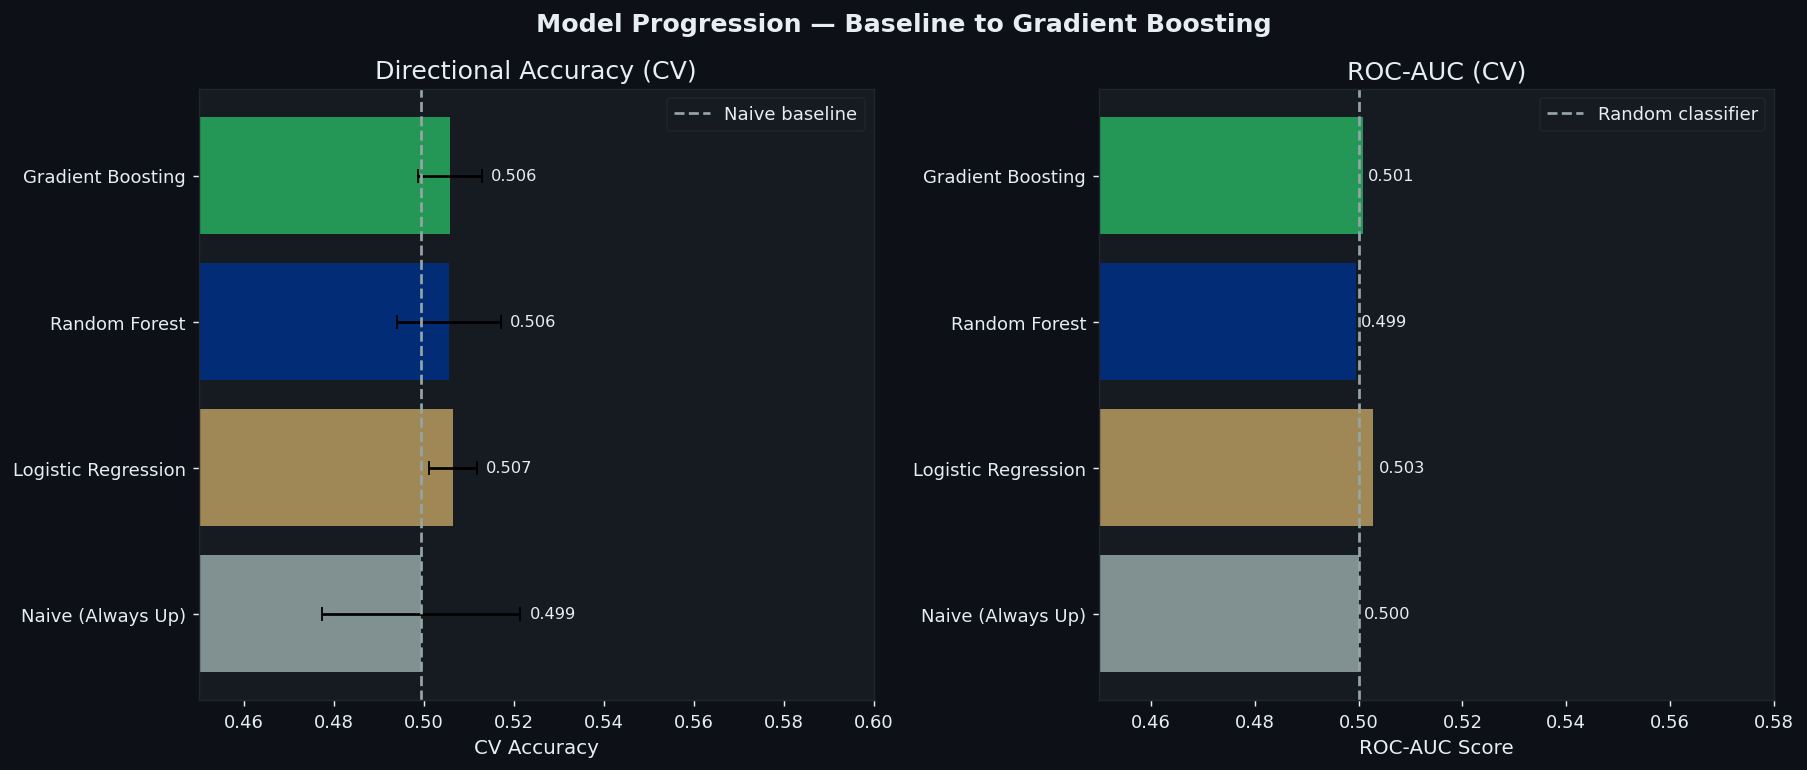

In [16]:
# ── Model comparison visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Progression — Baseline to Gradient Boosting',
             fontsize=14, fontweight='bold')

names = list(results.keys())
accs  = [results[n]['acc'] for n in names]
aucs  = [results[n]['auc'] for n in names]
stds  = [results[n]['std'] for n in names]
palette = [COLORS['neutral'], COLORS['jpm_gold'], COLORS['jpm_blue'], COLORS['bull']]

ax = axes[0]
bars = ax.barh(names, accs, xerr=stds, color=palette, alpha=0.85,
               error_kw=dict(color=COLORS['text'], lw=1.5, capsize=4))
ax.axvline(accs[0], color=COLORS['neutral'], lw=1.5, ls='--', label='Naive baseline')
ax.set_xlabel('CV Accuracy')
ax.set_title('Directional Accuracy (CV)')
ax.set_xlim(0.45, 0.60)
for i, (v, s) in enumerate(zip(accs, stds)):
    ax.text(v + s + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
ax.legend()

ax = axes[1]
ax.barh(names, aucs, color=palette, alpha=0.85)
ax.axvline(0.5, color=COLORS['neutral'], lw=1.5, ls='--', label='Random classifier')
ax.set_xlabel('ROC-AUC Score')
ax.set_title('ROC-AUC (CV)')
ax.set_xlim(0.45, 0.58)
for i, v in enumerate(aucs):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
ax.legend()

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('model_comparison.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

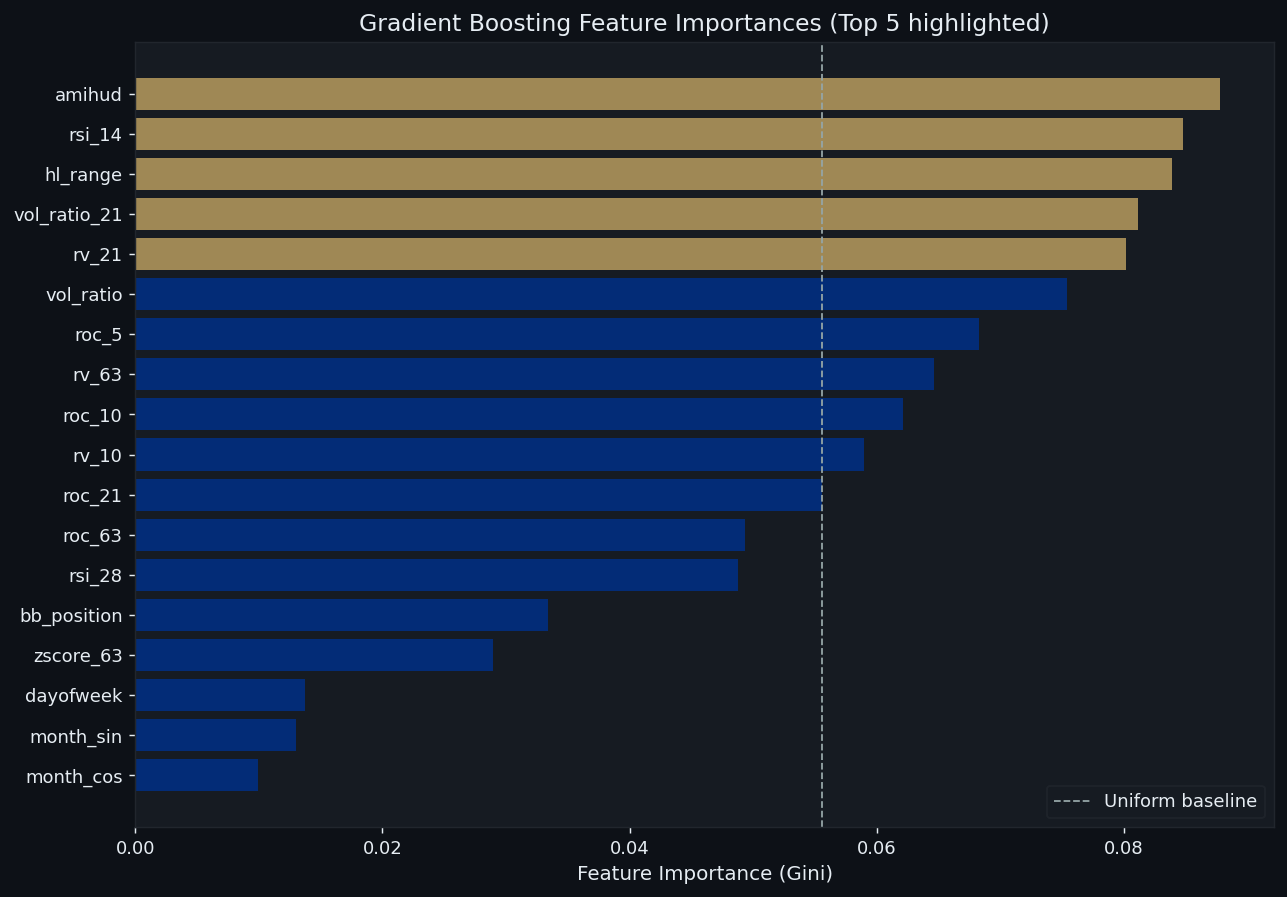


Top 5 features:


,Feature,Importance
9,rv_21,0.080199
14,vol_ratio_21,0.081152
13,hl_range,0.083882
4,rsi_14,0.084787
12,amihud,0.087769


In [17]:
# ── Feature Importance from best model (Gradient Boosting) ─────────────
# Re-train on full training window for feature importance
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

gb = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                  learning_rate=0.05, subsample=0.8, random_state=SEED)
gb.fit(X_train, y_train)
importances = gb.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = [COLORS['jpm_gold'] if i >= len(importance_df)-5 else COLORS['jpm_blue']
             for i in range(len(importance_df))]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors_fi, alpha=0.85)
ax.set_title('Gradient Boosting Feature Importances (Top 5 highlighted)', fontsize=13)
ax.set_xlabel('Feature Importance (Gini)')
ax.axvline(1/len(feature_cols), color=COLORS['neutral'], lw=1, ls='--',
           label='Uniform baseline')
ax.legend()
plt.tight_layout()
if not IN_COLAB:
  plt.savefig('feature_importance.png', bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

print("\nTop 5 features:")
display(importance_df.tail(5)[['Feature','Importance']])

#### **What Worked, What Didn't, and Candid Takeaways**

In [18]:
# ── Final hold-out evaluation ───────────────────────────────────────────
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred_gb   = gb.predict(X_test)
y_prob_gb   = gb.predict_proba(X_test)[:, 1]
y_naive     = np.ones(len(y_test), dtype=int)

print("=" * 55)
print("HOLD-OUT TEST SET EVALUATION (Last 20% of data)")
print("=" * 55)
print(f"\nNaive Baseline   Acc: {accuracy_score(y_test, y_naive):.4f} | AUC: 0.5000")
print(f"Gradient Boost   Acc: {accuracy_score(y_test, y_pred_gb):.4f} | AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")
print()
print("Classification Report — Gradient Boosting:")
print(classification_report(y_test, y_pred_gb, target_names=['Down', 'Up']))

HOLD-OUT TEST SET EVALUATION (Last 20% of data)

Naive Baseline   Acc: 0.5219 | AUC: 0.5000
Gradient Boost   Acc: 0.4998 | AUC: 0.4972

Classification Report — Gradient Boosting:
              precision    recall  f1-score   support

        Down       0.48      0.45      0.46      1104
          Up       0.52      0.55      0.53      1205

    accuracy                           0.50      2309
   macro avg       0.50      0.50      0.50      2309
weighted avg       0.50      0.50      0.50      2309

